In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [2]:
using DataFrames

In [3]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (2), wrong dep version loaded (4))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x6706632b011b9291, 0xf944d3804c928cab, 0xc96a2901bfb5e634, 0xb1528a7f67c6be70, 0x55c7d1cb528b55cf, 0xc9e8bc3eaf04e543, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [4]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 10.0, r = 1.0, η = 1.1), (m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = DiscreteUniform(a=2, b=200), r = Uniform{Float64}(a=1.0e-8, b=1.0), η = Uniform{Float64}(a=1.01, b=100.0)), Newtrinos.osc.var"#get_Nnaturalness#55"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{

In [5]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [6]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [ ]:
p = Newtrinos.get_params(experiments)

(N = 10.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [8]:
all_priors = Newtrinos.get_priors(experiments)

(N = DiscreteUniform(a=2, b=200), m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), r = Uniform{Float64}(a=1.0e-8, b=1.0), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), η = Uniform{Float64}(a=1.01, b=100.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976))

In [9]:
#=using CairoMakie
E_range = range(0.002, 0.04, length=100) 
L=1.663
L_vec = [L]


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(100), r=ftype(1e-2),m₀= ftype(0.01)))


probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
#lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=100", linewidth=2, color=:blue)


# Add legend and set limits
axislegend(ax, position=:rb)

display(fig)=#


In [10]:
using Revise
using CairoMakie

fig = experiments.dayabay.plot(p)

display(fig)


CairoMakie.Screen{SVG}


In [ ]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = (r=31, N=31)  
#vars_to_scan=(m₀=31,   N=31)

modified_priors = (
    N = DiscreteUniform(2, 50),
    m₀ =LogUniform(1e-4, 0.1),
    r =Uniform(1e-8, 1.0),#all_priors.r, 
   
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ =p.Δm²₃₁ , 
    δCP = p.δCP,  
    
    η=p.η,
    θ₁₂ = p.θ₁₂,    
    θ₁₃=p.θ₁₃,       
    θ₂₃ = p.θ₂₃   
    

)


In [ ]:

likelihood = Newtrinos.generate_likelihood(experiments);


In [ ]:

result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

In [ ]:
display(minimum(result.values.llh))

In [ ]:
m0=p.m₀

In [ ]:
bf = Newtrinos.bestfit(result)

In [ ]:
JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=$(m0)_NNM_NO.jld2" result

In [ ]:
using CairoMakie

In [ ]:
img = CairoMakie.plot(result; title="Daya Bay LogLikelihood r vs N, NND NO, mo=$m0,  η=2", log=0, mass=0, log_colormap=true)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/dayabay_Nr_m0=$(m0)_η=100_NND_NO.png", img)

In [ ]:

all_priors = Newtrinos.get_priors(experiments)

rr=1

par= merge(p, (r=rr,))
  
vars_to_scan = ( m₀=31, N=31)  

modified_priors = (
    N = DiscreteUniform(2,50),
    m₀ =all_priors.m₀,
    r = par.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,   
    θ₂₃ = par.θ₂₃
)
    

likelihood_NN = Newtrinos.generate_likelihood(experiments);

result = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

JLD2.@save "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_m0N_r=$(rr)_η=1+1N_NND_NO.jld2" result

In [ ]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result; title="DAYA BAY LogLikelihood m₀ vs N, r=$rr NND NO ", log=1, mass=1, log_colormap=true)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/dayabay_m0N_r=$(rr)_η=1+1N_NND_NO.png", img)

In [ ]:

function compute_lambda(r, N)
    η=1+1/N
    b=1/(N)
    l=0.05
    ms=100*1e9
    
    Lambda=sqrt((m0*l*N*ms)/(b^2*r*(η-1)))/1e9

    return Lambda
end


# Create the lambda grid
lambda_grid = [compute_lambda(p1, p2) for p1 in result.axes[1], p2 in result.axes[2]]

img1 = CairoMakie.plot(result, title=" ΛH Distribution (GeV) for b~10^-6 and η=1+1/N", log=1, values_to_plot=lambda_grid)
display("image/png", img1)


In [ ]:
# Define parameter ranges
param_axes = (
    r = logrange(1e-8, 1, 31),
    N = LinRange(2, 1e3, 31)
)

# Define values with log_posterNOr
values = (
    log_posterNOr = zeros(31, 31),
)

# Create result1
result1 = NewtrinosResult(axes=param_axes, values=values)

# Create the lambda grid
lambda_grid = [compute_lambda(p1, p2) for p1 in result1.axes[1], p2 in result1.axes[2]]

# Plot
img1 = CairoMakie.plot(result1, title="ΛH Distribution (GeV) for b~10^-6 and η=1+1/N", log=1, values_to_plot=lambda_grid)
display("image/png", img1)

In [ ]:
using CairoMakie
using ColorSchemes
using LaTeXStrings


function compute_lambda(r, N)
    η=1+1/N
    b=1e-6
    l=0.05
    ms=100*1e9
    m0=0.01
    
    Lambda=sqrt((m0*l*N*ms)/(b^2*r*(η-1)))/1e9

    return Lambda
end

# ===================== PARAMETER GRID =====================

r_vals = logrange(1e-8, 1, 31)
N_vals = LinRange(2, 1e3, 31)

# Compute Lambda_H grid
lambda_grid = [
    compute_lambda(r, N)
    for r in r_vals, N in N_vals
]

# Avoid log(0) issues
lambda_grid .= max.(lambda_grid, eps())

# ===================== FIGURE =====================

fig = Figure(size = (1200, 800))

ax = Axis(
    fig[1, 1],
    title =L"\Lambda_H"*"distribution - b ∼ 10⁻⁶, m₀ = 0.01 eV, η = 1 + 1/N", #L"\Lambda_H\ \mathrm{distribution}\ - b \sim 10^{-6},\ m_0 = 0.01 eV,\ \eta = 1 + 1/N",
    xlabel = "r",
    ylabel = "N",

    xscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = true,
    yminorticksvisible = true,
    yminorgridvisible = true,
    titlesize = 34,
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 24,
    yticklabelsize = 24,
)

# ===================== HEATMAP =====================

hm = heatmap!(
    ax,
    r_vals,
    N_vals,
    lambda_grid;
    colormap = ColorSchemes.GnBu,
    colorscale = log10
)

# ===================== COLORBAR =====================
# ===================== BLACK CONTOUR LINE =====================

Λ_level = 1e4   # <<< choose your physics scale here (GeV)

contour!(
    ax,
    r_vals,
    N_vals,
    lambda_grid;
    levels = [Λ_level],
    color = :black,
    linewidth = 3,
    label = L"\Lambda_H"*"= 10 TeV"  ,
)

Colorbar(
    fig[1, 2],
    hm;
    label = L"\Lambda_H"*(" [GeV]"),
    labelsize = 24,
    ticklabelsize = 24,
    width = 18
)

axislegend(ax, position = :rb, framevisible = false, labelsize = 28)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/cutoff_new.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/cutoff_new.svg", fig)


In [ ]:
using CairoMakie
using ColorSchemes
using LaTeXStrings

# ===================== PARAMETER GRID =====================

r_vals = logrange(1e-8, 1, 31)
N_vals = LinRange(2, 1e5, 31)

lambda_grid = [
    compute_lambda(r, N)
    for r in r_vals, N in N_vals
]

lambda_grid .= max.(lambda_grid, eps())  # safety for log

# ===================== FIGURE =====================

fig = Figure(size = (1200, 800))

ax = Axis(
    fig[1, 1],
    title = L"\Lambda_H\ \mathrm{distribution}\ (b \sim \frac{1}{N},\ \eta = 1 + 1/N)",
    xlabel = "r",
    ylabel = "N",
    xscale = log10,

    titlesize = 24,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 16,
    yticklabelsize = 16,

    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
)

# ===================== HEATMAP =====================

hm = heatmap!(
    ax,
    r_vals,
    N_vals,
    lambda_grid;
    colormap = ColorSchemes.GnBu,
    colorscale = log10
)

# ===================== BLACK CONTOUR LINE =====================

Λ_level = 1e4   # <<< choose your physics scale here (GeV)

contour!(
    ax,
    r_vals,
    N_vals,
    lambda_grid;
    levels = [Λ_level],
    color = :black,
    linewidth = 2.5
)

# ===================== COLORBAR =====================

Colorbar(
    fig[1, 2],
    hm;
    label = L"\Lambda_H\ \mathrm{[GeV]}",
    labelsize = 18,
    ticklabelsize = 14,
    width = 18
)

display("image/png", fig)

save("/home/sofialon/Newtrinos.jl/plots_fix/abs_phen/lambdaH_cutoff2.png", fig)


In [ ]:
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterNOr[:, 15]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterNOr[:, 15]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel = "r",
    ylabel = "Log PosterNOr",
    title = "r vs Log posterNOr - Dayabay NND",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterNOr[:, 25],
    color = :blue,
    linewidth = 2,
    label = "Log PosterNOr"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_rLogpost_N=50_m0=0.1_NND.png", fig)


Oscillations


In [ ]:
using Revise
using Newtrinos
using CairoMakie

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

p_5  = merge(p, (N=ftype(5),  r=ftype(1),))
p_10 = merge(p, (N=ftype(10), r=ftype(1),))
p_20 = merge(p, (N=ftype(20), r=ftype(1),))
p_50 = merge(p, (N=ftype(50), r=ftype(1),))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_5  = osc_prob(E_vals, L_vec, p_5; anti=true)
probab_10 = osc_prob(E_vals, L_vec, p_10; anti=true)
probab_20 = osc_prob(E_vals, L_vec, p_20; anti=true)
probab_50 = osc_prob(E_vals, L_vec, p_50; anti=true)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig = Figure(size=(900,650))

ax = Axis(
    fig[1,1],
    xlabel = L"L/E\;(\mathrm{km/GeV})",
    ylabel = L"P(\bar{\nu}_e \rightarrow \bar{\nu}_e)",
    title = "Daya Bay + JUNO Coverage",
    xscale = log10
)

lines!(ax, LE_range, probab_SM[:,1,1,1],
    color=:black,
    linewidth=3,
    label="SM")

lines!(ax, LE_range, probab_5[:,1,1,1],
    linewidth=2,
    label="N = 5")

lines!(ax, LE_range, probab_10[:,1,1,1],
    linewidth=2,
    label="N = 10")

lines!(ax, LE_range, probab_20[:,1,1,1],
    linewidth=2,
    label="N = 20")

lines!(ax, LE_range, probab_50[:,1,1,1],
    linewidth=2,
    label="N = 50")

axislegend(ax, position=:rb)

ylims!(ax, 0.10, 1.01)

# Mark experiment regions
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray)   # DB peak region
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray) 
vlines!(ax, [52.5/0.01], linestyle=:dash, color=:gray)    # JUNO peak region

text!(400, 0.99, text="Daya Bay")
text!(13000, 0.99, text="JUNO")

display("image/png", fig)

# save("oscillation_probability_LE_dayabay_juno.png", fig)

In [ ]:
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

p_5  = merge(p, (N=ftype(5),  r=ftype(1),))
p_10 = merge(p, (N=ftype(10), r=ftype(1),))
p_20 = merge(p, (N=ftype(20), r=ftype(1),))
p_50 = merge(p, (N=ftype(50), r=ftype(1),))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_5  = osc_prob(E_vals, L_vec, p_5; anti=true)
probab_10 = osc_prob(E_vals, L_vec, p_10; anti=true)
probab_20 = osc_prob(E_vals, L_vec, p_20; anti=true)
probab_50 = osc_prob(E_vals, L_vec, p_50; anti=true)

# ------------------------------------------------------------
# PLOT - PAPER READY STYLE
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical)
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # N=50
c_2 = palette[2]  # SM
c_3 = palette[3]  # N=5
c_4 = palette[4]  # N=10
c_5 = palette[5]  # N=20

fig = Figure(resolution=(900, 650), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = L"L/E \;(\mathrm{km/GeV})",
    ylabel = L"P(\bar{\nu}_e \rightarrow \bar{\nu}_e)",
    #title = "Oscillation Probabilities - Dirac NO, r=1, m₀=0.01 eV, η=1+1/N ",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=false,
    ygridvisible=false,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true,
    xscale = log10
)

# Line plots
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label="SM", linewidth=2.5, color=:black)

lines!(ax, LE_range, probab_5[:,1,1,1],
    label="N = 5", linewidth=2, color=c_3)

lines!(ax, LE_range, probab_10[:,1,1,1],
    label="N = 10", linewidth=2, color=c_4)

lines!(ax, LE_range, probab_20[:,1,1,1],
    label="N = 20", linewidth=2, color=c_5)

lines!(ax, LE_range, probab_50[:,1,1,1],
    label="N = 50", linewidth=2, color=c_2)


# Axis limits
ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

# Legend
axislegend(ax, position=:lb, framevisible=false, labelsize=28)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions
text!(ax, 370, 0.2, text="Daya Bay", fontsize=20, color=:gray40)
text!(ax, 13000, 0.9, text="JUNO", fontsize=20, color=:gray40)

# Display and save
display("image/png", fig)

# Save options (update paths as needed)
save("/home/sofialon/Newtrinos.jl/plots_svg/oscillation_probability_LE_dayabay_juno_paper_N.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/oscillation_probability_LE_dayabay_juno_paper_N.svg", fig)

In [ ]:
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

p_5  = merge(p, (N=ftype(5),  r=ftype(1),))
p_10 = merge(p, (N=ftype(10), r=ftype(1),))
p_20 = merge(p, (N=ftype(20), r=ftype(1),))
p_50 = merge(p, (N=ftype(50), r=ftype(1),))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_5  = osc_prob(E_vals, L_vec, p_5; anti=true)
probab_10 = osc_prob(E_vals, L_vec, p_10; anti=true)
probab_20 = osc_prob(E_vals, L_vec, p_20; anti=true)
probab_50 = osc_prob(E_vals, L_vec, p_50; anti=true)

# ------------------------------------------------------------
# PLOT - PRD PAPER READY STYLE (BIGGER VERSION)
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical) - ORIGINAL ASSIGNMENTS PRESERVED
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # N=50
c_2 = palette[2]  # SM (black in original, but we'll use palette[2] for consistency)
c_3 = palette[3]  # N=5
c_4 = palette[4]  # N=10
c_5 = palette[5]  # N=20

# PRD single column width (8.6 cm) with appropriate height
fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)",  # No LaTeX
    ylabel = "P(ν̄ₑ → ν̄ₑ)",  # Simple text, no LaTeX
    xlabelsize = 16,
    ylabelsize = 16,
    titlesize = 18,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = false,
     ygridvisible = false,
    #xgridcolor = :gray90,
    #ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true,
    xminorticksvisible = true,
    yminorticksvisible = true,
    #xminorgridvisible = true,
    #yminorgridvisible = true,
    xscale = log10
)

# Line plots with original color assignments and 2.5 pt linewidth
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label = "SM", linewidth = 2, color = :black)  # SM stays black

lines!(ax, LE_range, probab_5[:,1,1,1],
    label = "N = 5", linewidth = 2, color = c_3)

lines!(ax, LE_range, probab_10[:,1,1,1],
    label = "N = 10", linewidth = 2, color = c_4)

lines!(ax, LE_range, probab_20[:,1,1,1],
    label = "N = 20", linewidth = 2, color = c_5)

lines!(ax, LE_range, probab_50[:,1,1,1],
    label = "N = 50", linewidth = 2, color = c_2)


# Axis limits
ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

# Create legend with box matching PRD style (BIGGER VERSION)
legend_elements = [
    LineElement(color=:black, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_3, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_4, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_5, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_2, linewidth=2.5, linestyle=:solid)
]

legend_labels = ["SM", "N = 5", "N = 10", "N = 20", "N = 50"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :left,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Oscillation Probabilities",
    titlefont = :bold,
    titlesize = 16
)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions (BIGGER fonts)
text!(ax, 370, 0.2, text = "Daya Bay", fontsize = 14, color = :gray40)
text!(ax, 13000, 0.9, text = "JUNO", fontsize = 14, color = :gray40)

# Display and save
display(fig)

# Save options (update paths as needed)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_N.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_N.svg", fig)

In [ ]:
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS - VARYING r
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

# Fixed N = 20, varying r
p_r0   = merge(p, (N=ftype(20), r=ftype(1e-6),))
p_r025 = merge(p, (N=ftype(20), r=ftype(1e-4),))
p_r05  = merge(p, (N=ftype(20), r=ftype(0.5),))
p_r1   = merge(p, (N=ftype(20), r=ftype(1),))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_r0   = osc_prob(E_vals, L_vec, p_r0; anti=true)
probab_r025 = osc_prob(E_vals, L_vec, p_r025; anti=true)
probab_r05  = osc_prob(E_vals, L_vec, p_r05; anti=true)
probab_r1   = osc_prob(E_vals, L_vec, p_r1; anti=true)

# ------------------------------------------------------------
# PLOT - PAPER READY STYLE (VARYING r)
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical)
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # r=1
c_2 = palette[2]  # SM (will be black)
c_3 = palette[3]  # r=1e-6
c_4 = palette[4]  # r=0.1
c_5 = palette[5]  # r=0.5

fig = Figure(resolution=(900, 650), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = L"L/E \;(\mathrm{km/GeV})",
    ylabel = L"P(\bar{\nu}_e \rightarrow \bar{\nu}_e)",
    #title = "Oscillation Probabilities - Dirac NO, N=20, m₀=0.01 eV, η=1+1/N",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=false,
    ygridvisible=false,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true,
    xscale = log10
)

# Line plots
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label="SM", linewidth=2.5, color=:black)

lines!(ax, LE_range, probab_r0[:,1,1,1],
    label="r = 10⁻⁶", linewidth=2, color=c_3)

lines!(ax, LE_range, probab_r025[:,1,1,1],
    label="r = 10⁻⁴", linewidth=2, color=c_4)

lines!(ax, LE_range, probab_r05[:,1,1,1],
    label="r = 0.5", linewidth=2, color=c_5)

lines!(ax, LE_range, probab_r1[:,1,1,1],
    label="r = 1", linewidth=2, color=c_2)

# Axis limits
ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

# Legend
axislegend(ax, position=:lb, framevisible=false, labelsize=28)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions
text!(ax, 370, 0.2, text="Daya Bay", fontsize=20, color=:gray40)
text!(ax, 13000, 0.9, text="JUNO", fontsize=20, color=:gray40)

# Display and save
display("image/png", fig)

# Save options (update paths as needed)
save("/home/sofialon/Newtrinos.jl/plots_svg/oscillation_probability_LE_dayabay_juno_paper_r.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/oscillation_probability_LE_dayabay_juno_paper_r.svg", fig)

[ Info: Loading dayabay data


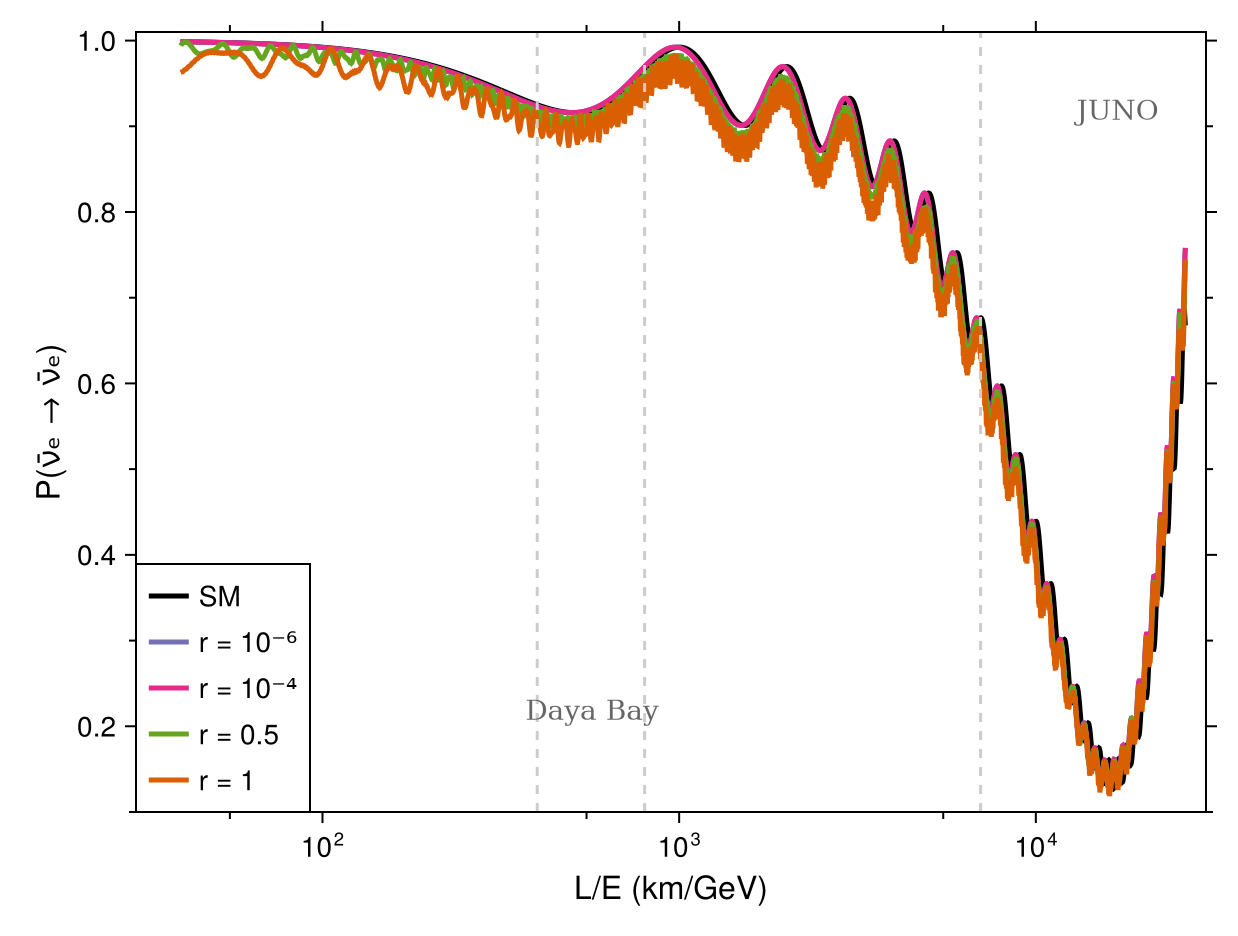

CairoMakie.Screen{SVG}


In [28]:
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS - VARYING r
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

# Fixed N = 20, varying r
p_r0   = merge(p, (N=ftype(10), r=ftype(1e-6),))
p_r025 = merge(p, (N=ftype(10), r=ftype(1e-4),))
p_r05  = merge(p, (N=ftype(11), r=ftype(0.5),))
p_r1   = merge(p, (N=ftype(10), r=ftype(1),))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_r0   = osc_prob(E_vals, L_vec, p_r0; anti=true)
probab_r025 = osc_prob(E_vals, L_vec, p_r025; anti=true)
probab_r05  = osc_prob(E_vals, L_vec, p_r05; anti=true)
probab_r1   = osc_prob(E_vals, L_vec, p_r1; anti=true)

# ------------------------------------------------------------
# PLOT - PRD PAPER READY STYLE (BIGGER VERSION) - VARYING r
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical) - ORIGINAL ASSIGNMENTS PRESERVED
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # r=1 (will use c_2 for SM)
c_2 = palette[2]  # SM (black)
c_3 = palette[3]  # r=1e-6
c_4 = palette[4]  # r=1e-4
c_5 = palette[5]  # r=0.5

# PRD single column width (8.6 cm) with appropriate height
fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)",  # No LaTeX
    ylabel = "P(ν̄ₑ → ν̄ₑ)",  # Simple text, no LaTeX
    xlabelsize = 16,
    ylabelsize = 16,
    titlesize = 18,
    xticklabelsize = 14,
    yticklabelsize = 14,
    xgridvisible = false,
    ygridvisible = false,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true,
    xminorticksvisible = true,
    yminorticksvisible = true,
    #xminorgridvisible = true,
    #yminorgridvisible = true,
    xscale = log10
)

# Line plots with original color assignments and 2.5 pt linewidth
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label = "SM", linewidth = 2.5, color = :black)  # SM stays black

lines!(ax, LE_range, probab_r0[:,1,1,1],
    label = "r = 10⁻⁶", linewidth = 2.5, color = c_3)

lines!(ax, LE_range, probab_r025[:,1,1,1],
    label = "r = 10⁻⁴", linewidth = 2.5, color = c_4)

lines!(ax, LE_range, probab_r05[:,1,1,1],
    label = "r = 0.5", linewidth = 2.5, color = c_5)

lines!(ax, LE_range, probab_r1[:,1,1,1],
    label = "r = 1", linewidth = 2.5, color = c_2)

# Axis limits
ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

# Create legend with box matching PRD style (BIGGER VERSION)
legend_elements = [
    LineElement(color=:black, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_3, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_4, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_5, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_2, linewidth=2.5, linestyle=:solid)
]

legend_labels = ["SM", "r = 10⁻⁶", "r = 10⁻⁴", "r = 0.5", "r = 1"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :left,
    valign = :bottom,
    labelsize = 14,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Oscillation Probabilities",
    titlefont = :bold,
    titlesize = 16
)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions (scaled for PRD)
text!(ax, 370, 0.2, text = "Daya Bay", fontsize = 14, color = :gray40)
text!(ax, 13000, 0.9, text = "JUNO", fontsize = 14, color = :gray40)

# Display and save
display(fig)

# Save options (update paths as needed)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_r.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_r.svg", fig)

In [ ]:
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS - VARYING r
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

# Fixed N = 20, varying r
p_r0   = merge(p, (N=ftype(20), r=ftype(1e-6),))
p_r025 = merge(p, (N=ftype(20), r=ftype(0.1),))
p_r05  = merge(p, (N=ftype(20), r=ftype(0.5),))
p_r1   = merge(p, (N=ftype(20), r=ftype(1),))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_r0   = osc_prob(E_vals, L_vec, p_r0; anti=true)
probab_r025 = osc_prob(E_vals, L_vec, p_r025; anti=true)
probab_r05  = osc_prob(E_vals, L_vec, p_r05; anti=true)
probab_r1   = osc_prob(E_vals, L_vec, p_r1; anti=true)

# ------------------------------------------------------------
# PLOT - PAPER READY STYLE (VARYING r)
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical)
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # r=1
c_2 = palette[2]  # SM
c_3 = palette[3]  # r=1e-6
c_4 = palette[4]  # r=0.1
c_5 = palette[5]  # r=0.5

fig = Figure(resolution=(900, 650), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = L"L/E \;(\mathrm{km/GeV})",
    ylabel = L"P(\bar{\nu}_e \rightarrow \bar{\nu}_e)",
    title = "Daya Bay + JUNO Coverage — Dirac — NO, N=20",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true,
    xscale = log10
)

# Line plots
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label="SM", linewidth=2.5, color=:black)

lines!(ax, LE_range, probab_r0[:,1,1,1],
    label="r = 10⁻⁶", linewidth=2.5, color=c_3)

lines!(ax, LE_range, probab_r025[:,1,1,1],
    label="r = 0.1", linewidth=2.5, color=c_4)

lines!(ax, LE_range, probab_r05[:,1,1,1],
    label="r = 0.5", linewidth=2.5, color=c_5)

lines!(ax, LE_range, probab_r1[:,1,1,1],
    label="r = 1", linewidth=2.5, color=c_1)

# Axis limits
ylims!(ax, 0.10, 1.01)

# Legend
axislegend(ax, position=:lb, framevisible=false, labelsize=28)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.01], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions
text!(ax, 400, 0.2, text="Daya Bay", fontsize=20, color=:gray40)
text!(ax, 13000, 0.99, text="JUNO", fontsize=20, color=:gray40)

# Display and save
display("image/png", fig)

# Save options (update paths as needed)
# save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_LE_N_NND_NO_r.png", fig)
# save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_LE_N_NND_NO_r.svg", fig)

In [ ]:
using Revise
using Newtrinos
# STANDARD MODEL
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers);


experiments_SM = (
 
    dayabay = Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

In [ ]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(5), r= ftype(1),))
p_10 = merge(p, (N = ftype(10),r= ftype(1),))
p_20 = merge(p, (N = ftype(20),r= ftype(1),))
p_50 = merge(p, (N = ftype(50),r= ftype(1),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)

p_0 = merge(p, (N = ftype(20),r= ftype(1e-4),))
p_025 = merge(p,  (N = ftype(20),r= ftype(0.1),))
p_05 = merge(p,  (N = ftype(20),r= ftype(0.5),))
p_1 = merge(p,  (N = ftype(20),r= ftype(1),))

probab_0 = osc_prob(collect(E_range), L_vec, p_0; anti=true)
probab_025 = osc_prob(collect(E_range), L_vec, p_025; anti=true)
probab_05 = osc_prob(collect(E_range), L_vec, p_05; anti=true)
probab_1 = osc_prob(collect(E_range), L_vec, p_1; anti=true)


In [ ]:
using CairoMakie

In [ ]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - NO, r=1"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=5", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="N=10", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" N=20", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" N=50", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/plots_fix/dayabay/osc_dayabay_N_NND_NO_N.png", fig)

display("image/png",fig)


In [ ]:
using ColorSchemes

palette = cgrad(:Dark2_8, categorical=true)

c_1  = palette[1]
c_2  = palette[2]
c_3 = palette[3]
c_4 = palette[4]
c_5 = palette[5]

fig = Figure(resolution=(800, 600), font="CMU Serif")
ax = Axis(fig[1, 1],
    xlabel = "Energy (GeV)",                   
    ylabel = "P(ν̄ₑ → ν̄ₑ)",
    title  = "Oscillation Probabilities DayaBay - Dirac - NO, r=1",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# Line plots (Dark2_8)
lines!(ax, E_range, probab_SM[:, 1, 1, 1],
    label="SM", linewidth=2.5, color=c_2)

lines!(ax, E_range, probab_5[:, 1, 1, 1],
    label="N = 5", linewidth=2.5, color=c_3)

lines!(ax, E_range, probab_10[:, 1, 1, 1],
    label="N = 10", linewidth=2.5, color=c_4)

lines!(ax, E_range, probab_20[:, 1, 1, 1],
    label="N = 20", linewidth=2.5, color=c_5)

lines!(ax, E_range, probab_50[:, 1, 1, 1],
    label="N = 50", linewidth=2.5, color=c_1)

# Legend
axislegend(ax, position=:rb, framevisible=false, labelsize=28)

display("image/png",fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_N.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_N.svg", fig)

In [ ]:
LE_range = L ./ E_range   # L/E in km/GeV if L is in km and E in GeV
fig = Figure(size=(800, 600))
ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)",
    title = "Oscillation Probabilities Dayabay - Dirac case - NO, r=1"
)

lines!(ax, LE_range, probab_SM[:,1,1,1], label="SM", linewidth=2, color=:green)
lines!(ax, LE_range, probab_5[:,1,1,1], label="N=5", linewidth=2, color=:blue)
lines!(ax, LE_range, probab_10[:,1,1,1], label="N=10", linewidth=2, color=:red)
lines!(ax, LE_range, probab_20[:,1,1,1], label="N=20", linewidth=2, color=:purple)
lines!(ax, LE_range, probab_50[:,1,1,1], label="N=50", linewidth=2, color=:orange)

axislegend(ax, position=:rb)

display("image/png", fig)

In [ ]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities DayaBay - Dirac - NO, N=20",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="SM", linewidth=2, color=c_2)
lines!(ax, E_range, probab_0[:, 1, 1, 1], label="r=10^-6", linewidth=2, color=c_3)
lines!(ax, E_range, probab_025[:, 1, 1, 1], label="r=0.1", linewidth=2, color=c_4)
lines!(ax, E_range, probab_05[:, 1, 1, 1], label="r=0.5", linewidth=2, color=c_5)
lines!(ax, E_range, probab_1[:, 1, 1, 1], label="r=1", linewidth=2, color=c_1)

# Add legend and set limits
axislegend(ax, position=:rb, framevisible=false, labelsize=28)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_r.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_r.svg", fig)

display("image/png",fig)

In [ ]:
# m0


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(20),m₀= ftype(0.1),))
p_10 = merge(p, (N = ftype(20), m₀= ftype(0.01),))
p_20 = merge(p, (N = ftype(20), m₀= ftype(1e-4),))
p_50 = merge(p, (N = ftype(20), m₀= ftype(1e-6),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)



In [ ]:
using ColorSchemes

palette = cgrad(:Dark2_8, categorical=true)

c_1  = palette[1]
c_2  = palette[2]
c_3 = palette[3]
c_4 = palette[4]
c_5 = palette[5]

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - NO, N=20, r=1",
     xlabelsize=28,
    ylabelsize=28,
    titlesize=22,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true

)


# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=c_2)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" m0=0.1 eV", linewidth=2, color=c_3)
lines!(ax, E_range, probab_10[:, 1, 1,1], label=" m0=0.01 eV", linewidth=2, color=c_4)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" m0=1e-4 eV", linewidth=2, color=c_5)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" m0=1e-6 eV", linewidth=2, color=c_1)

# Add legend and set limits
axislegend(ax, position=:rb, framevisible=false, labelsize=28)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_m0.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_m0.svg", fig)

display("image/png",fig)

In [ ]:
# ETA


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)
N=20
p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(20),η= ftype(1+1/N),))
p_10 = merge(p, (N = ftype(20), η= ftype(1+N),))
p_20 = merge(p, (N = ftype(20), η= ftype(2),))
p_50 = merge(p, (N = ftype(20), η= ftype(100),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)

In [ ]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - NO, N=20, r=1",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=22,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true

)
# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=c_2)
lines!(ax, E_range, probab_5[:, 1, 1,1], label="η=1+1/N ", linewidth=2, color=c_3)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="η=1+N", linewidth=2, color=c_4)
lines!(ax, E_range, probab_20[:, 1,1,1], label="η=2", linewidth=2, color=c_5)
lines!(ax, E_range, probab_50[:, 1,1,1], label="η=100", linewidth=2, color=c_1)


# Add legend and set limits
axislegend(ax, position=:rb, framevisible=false, labelsize=28)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_eta.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/osc_dayabay_N_NND_NO_eta.svg", fig)

display("image/png",fig)

In [ ]:
using CairoMakie

# --- Residuals (difference w.r.t. SM)
res_5  = probab_5[:, 1, 1, 1]  .- probab_SM[:, 1, 1, 1]
res_10 = probab_10[:, 1, 1, 1] .- probab_SM[:, 1, 1, 1]
res_20 = probab_20[:, 1, 1, 1] .- probab_SM[:, 1, 1, 1]
res_50 = probab_50[:, 1, 1, 1] .- probab_SM[:, 1, 1, 1]

# --- Figure with 2 rows (600 + 200)
fig = Figure(resolution=(800, 800), font="CMU Serif")

# =======================
# Main axis (top)
# =======================
ax = Axis(fig[1, 1],
   # xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)",
    title  = "Oscillation Probabilities Dayabay – Dirac case – NO, N=20, r=1, m₀ = 0.01 eV",
    #xlabelsize=20,
    ylabelsize=20,
    titlesize=18,
    xticklabelsize=16,
    yticklabelsize=16,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# Main curves
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="SM", linewidth=2.5, color=c_2)
lines!(ax, E_range, probab_5[:, 1, 1, 1],  label="η = 1 + 1/N", linewidth=2.5, color=c_3)
lines!(ax, E_range, probab_10[:, 1, 1, 1], label="η = 1 + N",   linewidth=2.5, color=c_4)
lines!(ax, E_range, probab_20[:, 1, 1, 1], label="η = 2",       linewidth=2.5, color=c_5)
lines!(ax, E_range, probab_50[:, 1, 1, 1], label="η = 100",     linewidth=2.5, color=c_1)

axislegend(ax, position=:rb, framevisible=false, fontsize=24)

# =======================
# Residuals axis (bottom)
# =======================
ax_res = Axis(fig[2, 1],
    xlabel = "Energy (GeV)",
    ylabel = "Residues",
    xlabelsize=18,
    ylabelsize=18,
    xticklabelsize=14,
    yticklabelsize=14,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

# Residual curves (same colors)
lines!(ax_res, E_range, res_5,  linewidth=2, color=c_3)
lines!(ax_res, E_range, res_10, linewidth=2, color=c_4)
lines!(ax_res, E_range, res_20, linewidth=2, color=c_5)
lines!(ax_res, E_range, res_50, linewidth=2, color=c_1)

# Reference zero line
hlines!(ax_res, 0.0, linestyle=:dash, color=:black, linewidth=1.5)

# Link x-axes
linkxaxes!(ax, ax_res)

# Row height control (600 top, 200 bottom)
rowsize!(fig.layout, 1, Relative(0.75))
rowsize!(fig.layout, 2, Relative(0.25))

display("image/png", fig)

save("/home/sofialon/Newtrinos.jl/plots_fix/osc_dayabay_NND_NO_eta_residuals.png", fig)


In [ ]:
a0=

In [ ]:
using CairoMakie
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    

params_temp = merge(p, (N=50, r =1, m₀=0.3))
matrix_e, matrix_m, matrix_t, FinalU, h_temp, gamma, gamma_sq = f1(params_temp)

params_temp_1= merge(p, (N=50, r =1, m₀=0.01))
matrix_e_1, matrix_m_1, matrix_t_1, FinalU_1, h_temp_1, gamma_1, gamma_sq_1  = f1(params_temp_1)


fig = Figure(size=(1200,1500))
ax1 = Axis(fig[1, 1])
hm = heatmap!(ax1, abs.(matrix_e), colormap=:viridis)
Colorbar(fig[1, 2], hm, label="Magnitude")
ax2 = Axis(fig[1,3])
hm = heatmap!(ax2, abs.(matrix_e_1.-matrix_e), colormap=:viridis)
Colorbar(fig[1, 4], hm, label="Magnitude")


ax1.title = " Matrix_1 m0=0.3 - N=50"
ax2.title = " Difference m0=0.3 vs m=0.01 - N=50"
ax1 = Axis(fig[2, 1])
hm = heatmap!(ax1, abs.(matrix_m), colormap=:viridis)
Colorbar(fig[2, 2], hm, label="Magnitude")
ax2 = Axis(fig[2,3])
hm = heatmap!(ax2, abs.(matrix_m_1.-matrix_m), colormap=:viridis)
Colorbar(fig[2, 4], hm, label="Magnitude")


ax1.title = " Matrix_2 m0=0.3 - N=50"
ax2.title = " Difference m0=0.3 vs m=0.01 - N=50"
ax1 = Axis(fig[3, 1])
hm = heatmap!(ax1, abs.(matrix_t), colormap=:viridis)
Colorbar(fig[3, 2], hm, label="Magnitude")
ax2 = Axis(fig[3,3])
hm = heatmap!(ax2, abs.(matrix_t_1.-matrix_t), colormap=:viridis)
Colorbar(fig[3, 4], hm, label="Magnitude")

ax1.title = " Matrix_3 m0=0.3 - N=50"
ax2.title = " Difference m0=0.3 vs m=0.01- N=50"

fig
    

#save("Matrix_3_50_diff_NND.png", fig)

In [ ]:
using CairoMakie
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    

params_temp = merge(p, (N=20, r =1, m₀=0.3))
EIG, FinalU, h_temp, gamma, gamma_sq = f1(params_temp)

params_temp_1= merge(p, (N=20, r =1, m₀=0.01))
EIG_1, FinalU_1, h_temp_1, gamma_1, gamma_sq_1  = f1(params_temp_1)


fig = Figure(size=(1200,500))
ax1 = Axis(fig[1, 1])
hm = heatmap!(ax1, abs.(EIG), colormap=:viridis)
Colorbar(fig[1, 2], hm, label="Magnitude")
ax2 = Axis(fig[1,3])
hm = heatmap!(ax2, abs.(EIG_1), colormap=:viridis)
Colorbar(fig[1, 4], hm, label="Magnitude")

ax1.title = " h m0=0.3 - N=20"
ax2.title = " h m0=0.01 - N=20"
fig
    


#save("/home/sofialon/Newtrinos.jl/plot_final/eigen_3N/NND/h_3_20_NND.png", fig)

Eigenvalues plotting

In [ ]:
using CairoMakie

# Plot 1: All eigenvalues vs m1 (scatter plot showing full structure)
function plot_eigenvalues_vs_m1(m1_values, all_eigenvalues)
    fig = Figure(size=(1200, 700))
    ax = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="Eigenvalue (eV²)",
        title="Full Eigenvalue Spectrum vs m₁ - N=20",
        yscale=log10)
    
    colors = [:blue, :red, :green, :orange, :purple, :brown, :pink, :cyan, :magenta, :yellow]
    
    # Plot eigenvalues at each m1 with color coding
    for (i, m1) in enumerate(m1_values)
        eigs = all_eigenvalues[i]  # This is a 1D vector
        if !isempty(eigs)
            color = colors[mod(i-1, length(colors)) + 1]
            # Plot each eigenvalue for this m1
            scatter!(ax, fill(m1, length(eigs)), eigs, 
                markersize=8, color=color, alpha=0.7, 
                label="m₁ = $(round(m1, sigdigits=2))")
        end
    end
    
    axislegend(ax, position=:rb, nbanks=2)
    fig
end


# Plot 2: Eigenvalue ratNOs vs eigenvalue index (colored by m1)
function plot_eigenvalue_ratNOs(m1_values, all_ratNOs)
    fig = Figure(size=(1200, 700))
    ax = Axis(fig[1, 1],
        xlabel="Eigenvalue Index RatNO (i+1 / i)",
        ylabel="RatNO Value",
        title="Consecutive Eigenvalue RatNOs - N=20",
        yscale=log10)
    
    colors = [:blue, :red, :green, :orange, :purple, :brown, :pink, :cyan, :magenta, :yellow]
    
    # Each m1 value gets its own color
    for (i, m1) in enumerate(m1_values)
        ratNOs = all_ratNOs[i]
        if !isempty(ratNOs)
            color = colors[mod(i-1, length(colors)) + 1]
            # Plot as line
            lines!(ax, 1:length(ratNOs), ratNOs, 
                   label="m₁ = $(round(m1, sigdigits=2))", 
                   linewidth=2.5, color=color)
            # Add markers separately
            scatter!(ax, 1:length(ratNOs), ratNOs,
                    markersize=7, color=color)
        end
    end
    
    # Add reference line at y=1 (NO hierarchy)
    hlines!(ax, [1.0], color=:black, linestyle=:dash, linewidth=2, label="NO structure", alpha=0.5)
    
    axislegend(ax, position=:rt, nbanks=2)
    fig
end


# Plot 3: Perturbation parameter vs m1
function plot_perturbation_parameter(m1_values, all_NOrm_ratNOs)
    fig = Figure(size=(1000, 700))
    ax = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="||M_gamma_factor|| / ||M_sector_part||",
        title="Perturbation Validity - N=10",
        yscale=log10
    )
    
    # Filter out NaN values
    valid_idx = .!isnan.(all_NOrm_ratNOs)
    valid_m1 = m1_values[valid_idx]
    valid_ratNOs = all_NOrm_ratNOs[valid_idx]
    
    if !isempty(valid_ratNOs)
        lines!(ax, valid_m1, valid_ratNOs, linewidth=3, color=:blue, label="NOrm ratNO")
        scatter!(ax, valid_m1, valid_ratNOs, markersize=10, color=:blue)
        
        # Add critical threshold lines
        hlines!(ax, [0.01], color=:green, linestyle=:dash, linewidth=2.5, 
                label="Safe perturbation (< 0.1)", alpha=0.7)
        hlines!(ax, [0.03], color=:orange, linestyle=:dash, linewidth=2.5, 
                label="Marginal (0.1-0.3)", alpha=0.7)
        hlines!(ax, [1.0], color=:red, linestyle=:dash, linewidth=2.5, 
                label="Breakdown (> 1)", alpha=0.7)
    end
    
    axislegend(ax, position=:rt)
    fig
end


# Main analysis function
function analyze_m1_limit(base_params, m1_values)
    """
    Analyze eigenvalue structure vs m1 to find the perturbation limit
    
    Args:
        base_params: NamedTuple with base parameters
        m1_values: Vector of m1 values to scan
        get_Nnaturalness_func: Your function that computes eigenvalues
        N_int: Number of sectors
        r: Sector parameter
    """
    
    all_eigenvalues = []
    all_ratNOs = []
    #all_NOrm_ratNOs = []
    
    for m1_test in m1_values
        println("Computing for m1 = $m1_test")
        
        # Update parameters with new m1
        params_test = merge(base_params, (m₀=m1_test,))
        
        try
            # Call your function - it should return eigenvalues
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            EIG, FinalU, h, NOrm_sector, NOrm_gamma = f1(params_test)
            
            # Extract ALL eigenvalues from the full matrix
            # Assuming EIG is a Diagonal matrix or eigenvalues vector
            if isa(EIG, Diagonal)
                eigs_sorted = (real.(diag(EIG)))
            else
                eigs_sorted = (real.(EIG))
            end
            
            push!(all_eigenvalues, eigs_sorted)
            
            # Compute ratNOs of consecutive eigenvalues
            if length(eigs_sorted) > 1
                ratNOs = eigs_sorted[2:end] ./ eigs_sorted[1:end-1]
                push!(all_ratNOs, ratNOs)
            else
                push!(all_ratNOs, [])
            end
            
            # Compute NOrm ratNO (perturbation parameter)
            #NOrm_ratNO = NOrm_gamma / NOrm_sector
            #push!(all_NOrm_ratNOs, NOrm_ratNO)
            
            #println("  -> $(length(eigs_sorted)) eigenvalues, NOrm ratNO = $(round(NOrm_ratNO, sigdigits=3))")
            
        catch e
            println("  Error: $e")
            push!(all_eigenvalues, [])
            push!(all_ratNOs, [])
            #push!(all_NOrm_ratNOs, NaN)
        end
    end
    
    return all_eigenvalues, all_ratNOs#, all_NOrm_ratNOs
end



function main(N_int)
    """
    Main function to run the analysis
    
    Usage: main(get_Nnaturalness)
    Pass your get_Nnaturalness function as argument
    """
    N=N_int
    
    # MODIFY THESE WITH YOUR ACTUAL VALUES
    base_params =merge(p, (N=20, r=1))
    
    # Logarithmic scan of m1 values
    m1_values = LinRange(0.008, 0.03,10)
    
   
    println("EIGENVALUE STRUCTURE ANALYSIS")
    
    println("Scanning m1 values: $(round.(m1_values, sigdigits=2))\n")
    
    all_eigenvalues, all_ratNOs= analyze_m1_limit(
        base_params, m1_values
    )
    
    println("GENERATING PLOTS")
    
    
    # Generate Plot 1: Eigenvalues vs m1
    println("Generating Plot 1: Eigenvalues vs m1...")
    fig1 = plot_eigenvalues_vs_m1(m1_values, all_eigenvalues)
    #save("/home/sofialon/Newtrinos.jl/plot_final/eigen_3N/NND/eigenvalues_vs_m1_3_$N.png", fig1)
    println("✓ Saved: eigenvalues_vs_m1_ex.png\n")
    
    # Generate Plot 2: Eigenvalue ratNOs
    println("Generating Plot 2: Eigenvalue ratNOs...")
    fig2 = plot_eigenvalue_ratNOs(m1_values, all_ratNOs)
    #save("/home/sofialon/Newtrinos.jl/plot_final/eigen_3N/NND/eigenvalue_ratNOs_vs_m1_3_$N.png", fig2)
    println("✓ Saved: eigenvalue_ratNOs_vs_m1.png\n")
    
    # Generate Plot 3: Perturbation parameter
    #=if !isempty(all_NOrm_ratNOs) && !all(isnan.(all_NOrm_ratNOs))
        println("Generating Plot 3: Perturbation parameter...")
        fig3 = plot_perturbation_parameter(m1_values, all_NOrm_ratNOs)
        #save("perturbation_parameter_vs_m1_ex_$N.png", fig3)
        println("✓ Saved: perturbation_parameter_vs_m1.png\n")
    else
        println("⚠ Skipping perturbation plot - NO valid NOrm ratNOs\n")
    end=#

    return fig1, fig2, all_eigenvalues, all_ratNOs#, all_NOrm_ratNOs
end


# To use this script:
# 1. Make sure your get_Nnaturalness function returns:
#    EIG, FinalUmatrix, h, NOrm_sector, NOrm_gamma
# 
fig1, fig2, eigs, ratNOs= main(20)
#
# Color scheme:
# - Blue: smallest m1 values
# - Red, Green, Orange, etc: progressively larger m1 values
# - Each color appears consistently across all three plots

Gamma plotting

In [ ]:


function plot_gamma_values(m1_values, all_gamma, all_gamma_squared)
    """
    Plot gamma and gamma^2 values vs m1
    
    Args:
        m1_values: Vector of m1 values
        all_gamma: Vector of gamma vectors (3 values each)
        all_gamma_squared: Vector of gamma^2 vectors (3 values each)
    """
    
    fig = Figure(size=(1400, 600))
    
    # Plot 1: gamma values
    ax1 = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="γ value",
        title="γ vs m₁ - N=10",
        yscale=log10)
    
    colors = [:blue, :red, :green]
    labels = ["γ₁ = m₁²/m₁²", "γ₂ = m₂²/m₁²", "γ₃ = m₃²/m₁²"]
    
    # Plot each gamma component
    for component in 1:3
        gamma_component = [all_gamma[i][component] for i in 1:length(m1_values)]
        lines!(ax1, m1_values, gamma_component, 
               linewidth=2.5, color=colors[component], label=labels[component])
        scatter!(ax1, m1_values, gamma_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax1, position=:rt)
    
    # Plot 2: gamma^2 values
    ax2 = Axis(fig[1, 2],
        xlabel="m₁ (eV)",
        ylabel="γ² value",
        title="γ² vs m₁  - N=50",
        yscale=log10)
    
    labels_sq = ["γ₁² = m₁⁴/m₁⁴", "γ₂² = m₂⁴/m₁⁴", "γ₃² = m₃⁴/m₁⁴"]
    
    # Plot each gamma^2 component
    for component in 1:3
        gamma_sq_component = [all_gamma_squared[i][component] for i in 1:length(m1_values)]
        lines!(ax2, m1_values, gamma_sq_component, 
               linewidth=2.5, color=colors[component], label=labels_sq[component])
        scatter!(ax2, m1_values, gamma_sq_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax2, position=:rt)
    
    fig
end


function plot_gamma_ratNO(m1_values, all_gamma, all_gamma_squared)
    """
    Plot ratNO γ²/γ for each component (should equal γ)
    """
    
    fig = Figure(size=(1200, 600))
    
    # Plot 1: RatNO γ²/γ
    ax1 = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="γ²/γ",
        title="RatNO γ²/γ vs m₁  - N=50",
        yscale=log10)
    
    colors = [:blue, :red, :green]
    labels = ["γ₁²/γ₁", "γ₂²/γ₂", "γ₃²/γ₃"]
    
    # Compute ratNOs γ²/γ for each component
    for component in 1:3
        ratNO_component = [all_gamma_squared[i][component] / all_gamma[i][component] 
                          for i in 1:length(m1_values)]
        lines!(ax1, m1_values, ratNO_component, 
               linewidth=2.5, color=colors[component], label=labels[component])
        scatter!(ax1, m1_values, ratNO_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax1, position=:rt)
    
    # Plot 2: Direct comparison γ vs γ²/γ (verification they're the same)
   #= ax2 = Axis(fig[1, 2],
        xlabel="m₁ (GeV)",
        ylabel="Value",
        title="Verification: γ (line) vs γ²/γ (scatter)",
        xscale=log10,
        yscale=log10)
    
    for component in 1:3
        gamma_component = [all_gamma[i][component] for i in 1:length(m1_values)]
        ratNO_component = [all_gamma_squared[i][component] / all_gamma[i][component] 
                          for i in 1:length(m1_values)]
        
        # Plot γ as line
        lines!(ax2, m1_values, gamma_component, 
               linewidth=2.5, color=colors[component], linestyle=:solid, alpha=0.7)
        # Plot γ²/γ as scatter to verify they match
        scatter!(ax2, m1_values, ratNO_component, 
                markersize=6, color=colors[component], marker=:circle)
    end
    =#
    fig
end


# Example usage:
function main_gamma(m1_values, base_params)
    """
    Main function to analyze gamma values
    
    Usage: main_gamma(m1_values, get_Nnaturalness, base_params)
    """
    
    all_gamma = []
    all_gamma_squared = []
    
    println("Computing gamma values for different m1...")
    
    for m1_test in m1_values
        params_test = merge(base_params, (m₀=m1_test,))
        
        try
            # Your function should return gamma values
            # Modify this based on what your get_Nnaturalness returns
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            EIG, FinalU, h, NOrm_sector, NOrm_gamma, gamma, gamma_sq = f1(params_test)
          
            
            push!(all_gamma, gamma)
            push!(all_gamma_squared, gamma_sq)
            
            println("m1 = $m1_test: γ = $gamma")
            
        catch e
            println("Error for m1 = $m1_test: $e")
        end
    end
    
    # Generate plots
    fig1 = plot_gamma_values(m1_values, all_gamma, all_gamma_squared)
    save("gamma_values_vs_m1_N50_NND.png", fig1)
    println("\n✓ Saved: gamma_values_vs_m1_N50_NND.png")

    fig2 = plot_gamma_ratNO(m1_values, all_gamma, all_gamma_squared)
    save("gamma_ratNOs_vs_m1_N50_NND.png", fig2)
    println("✓ Saved: gamma_ratNOs_vs_m1_N50_NND.png")
    
    return fig1, fig2, all_gamma, all_gamma_squared
end
   
# MODIFY THESE WITH YOUR ACTUAL VALUES
base_params =merge(p, (N=50, r=1))

# Logarithmic scan of m1 values
m1_values = LinRange(0.01, 0.05,10)

   
fig1, fig2, all_gamma, all_gamma_squared=main_gamma(m1_values, p)